# VQ-VAE + Structural Likelihood (Unary + Pairwise)

In [ ]:
# ====== Imports ======
from __future__ import annotations
import os, json, math
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from PIL import Image

import torchvision
import torchvision.transforms as T
from torchvision.utils import make_grid, save_image

import matplotlib.pyplot as plt
import numpy as np

try:
    from sklearn.metrics import roc_auc_score, roc_curve
    SKLEARN_OK = True
except ImportError:
    print("scikit-learn not found. Run: pip install scikit-learn")
    SKLEARN_OK = False

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.2.1+cu121
cuda available: True


## 0) Configuration
Set data paths, model size, and training/inference hyperparameters here.

In [ ]:
# ====== Config ======
CFG = {
    
    "train_dir": "./train",  
    "test_dir":  "./test",  

    "img_size": 256,        
    "channels": 1,          
    "normalize": True,      

    "batch_size": 32,
    "num_workers": 2,

    "out_dir":    "./runs/vqvae",
    "save_every": 5,         

    "base_channels": 64,     
    "num_codes":     512,     
    "code_dim":      64,      
    "vq_beta":       0.25,    
    "dropout":       0.1,     

    "vq_ema":               True,
    "vq_ema_decay":         0.99,
    "vq_ema_eps":           1e-5,
    "vq_restart_threshold": 1.0, 

    "epochs":       80,
    "lr":           1e-4,
    "weight_decay": 1e-4,    
    "recon_loss":   "mse",   
    "recon_weight": 1.0,

    "alpha": 1.0,          
    "use_h": True,        
    "use_v": True,         

    "lambda1":   1.0,       
    "lambda2":   2.0,      
    "aggregate": "topk",     
    "topk":      0.05,      
}

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
out_dir = Path(CFG["out_dir"])
out_dir.mkdir(parents=True, exist_ok=True)
(out_dir / "hparams.json").write_text(json.dumps(CFG, indent=2), encoding="utf-8")
print("device:", device)
print("out_dir:", out_dir.resolve())

device: cuda
out_dir: /home/yuw307/vqvae pipeline/runs/vqvae_marble


## 1) Dataset and DataLoader
Supports ImageFolder layout or flat-folder layout.

In [ ]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"}

class FlatFolderDataset(torch.utils.data.Dataset):

    def __init__(self, data_dir: str, transform=None):
        self.data_dir  = Path(data_dir)
        self.transform = transform
        self.filepaths = sorted([
            p for p in self.data_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMG_EXTS
        ])
        if len(self.filepaths) == 0:
            raise FileNotFoundError(
                f"No images found in {data_dir}\n"
                f"Supported: {IMG_EXTS}\n"
                f"Make sure images are directly in the folder, not in subfolders."
            )
        class_name          = self.data_dir.name
        self.classes        = [class_name]
        self.class_to_idx   = {class_name: 0}
        self.targets        = [0] * len(self.filepaths)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0


def build_transform(img_size: int, channels: int, augment: bool = False) -> T.Compose:
    """
    augment=True  → for training
    augment=False → for stats / testing
    """
    tfms = []
    if channels == 1:
        tfms.append(T.Grayscale(num_output_channels=1))

    if augment:
        crop_size = int(img_size * 1.15)
        tfms += [
            T.Resize((crop_size, crop_size)),
            T.RandomCrop(img_size),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.RandomApply([T.RandomRotation(degrees=(90, 90))], p=0.5),
            T.RandomApply([T.ColorJitter(brightness=0.15, contrast=0.15)], p=0.5),
        ]
    else:
        tfms.append(T.Resize((img_size, img_size)))

    tfms.append(T.ToTensor())

    if CFG.get("normalize", False):
        mean = [0.5] * channels
        std  = [0.5] * channels
        tfms.append(T.Normalize(mean=mean, std=std))  # → [-1, 1]

    return T.Compose(tfms)


def make_loader(data_dir: str, shuffle: bool):
    """
    shuffle=True  → augment=True  （for training）
    shuffle=False → augment=False （for stats / test）
    """
    transform = build_transform(CFG["img_size"], CFG["channels"], augment=shuffle)
    root      = Path(data_dir)

    valid_subdirs = [p for p in root.iterdir() if p.is_dir() and not p.name.startswith('.')]
    has_subdir = len(valid_subdirs) > 0
    if has_subdir:
        import torchvision.datasets as tvd
        class FilteredImageFolder(tvd.ImageFolder):
            def find_classes(self, directory):
                classes = [d.name for d in Path(directory).iterdir()
                           if d.is_dir() and not d.name.startswith('.')]
                classes.sort()
                
                priority = {}
                for c in classes:
                    if 'good' in c.lower():   priority[c] = 0
                    elif 'defect' in c.lower() or 'bad' in c.lower() or 'ng' in c.lower(): priority[c] = 1
                    else: priority[c] = 2 + classes.index(c)
                classes = sorted(classes, key=lambda c: priority[c])
                class_to_idx = {c: i for i, c in enumerate(classes)}
                return classes, class_to_idx
        ds = FilteredImageFolder(root=data_dir, transform=transform)
    else:
        ds = FlatFolderDataset(data_dir=data_dir, transform=transform)

    loader = DataLoader(
        ds,
        batch_size=CFG["batch_size"],
        shuffle=shuffle,
        num_workers=CFG["num_workers"],
        pin_memory=True,
        drop_last=False,
    )
    return loader, ds.class_to_idx, ds


# ── Build loaders ────────────────────────────────────────────────────
train_loader, train_label_map, train_ds = make_loader(CFG["train_dir"], shuffle=True)
test_loader,  test_label_map,  test_ds  = make_loader(CFG["test_dir"],  shuffle=False)

(out_dir / "train_label_map.txt").write_text(
    "\n".join(f"{k}\t{v}" for k,v in train_label_map.items()), encoding="utf-8")
(out_dir / "test_label_map.txt").write_text(
    "\n".join(f"{k}\t{v}" for k,v in test_label_map.items()),  encoding="utf-8")

print(f"train classes: {train_ds.classes}  |  train samples: {len(train_ds)}")
print(f"test  classes: {test_ds.classes}   |  test  samples: {len(test_ds)}")
print(f"train batches: {len(train_loader)} |  test  batches: {len(test_loader)}")

train classes: ['train2']  |  train samples: 1523
test  classes: ['good', 'defect']   |  test  samples: 545
train batches: 48 |  test  batches: 18


### 1.1 Preview a Training Batch
Sanity check the input size and normalization.

batch shape: torch.Size([32, 1, 256, 256]) | labels: [0, 0, 0, 0, 0, 0, 0, 0]


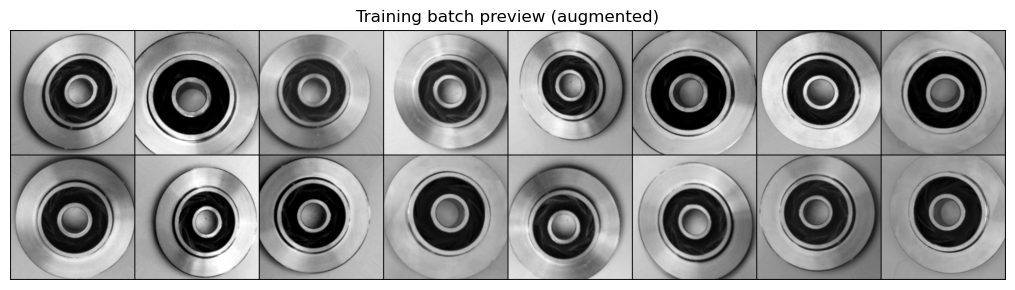

In [6]:
x0, y0 = next(iter(train_loader))
print("batch shape:", x0.shape, "| labels:", y0[:8].tolist())
grid = make_grid(x0[:16], nrow=8, normalize=True)
save_image(grid, str(out_dir / "train_batch_preview.png"))

plt.figure(figsize=(12,3))
plt.imshow(grid.permute(1,2,0).cpu(), cmap="gray" if CFG["channels"]==1 else None)
plt.axis("off")
plt.title("Training batch preview (augmented)")
plt.tight_layout()
plt.show()

## 2) VQ-VAE Model
Encoder/decoder with vector quantization (EMA codebook).

In [ ]:
class Encoder(nn.Module):
    def __init__(self, in_channels: int, base_channels: int, dropout: float = 0.0):
        super().__init__()
        c = base_channels
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, c, 4, 2, 1),
            nn.BatchNorm2d(c), nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(dropout),
            nn.Conv2d(c, 2*c, 4, 2, 1),
            nn.BatchNorm2d(2*c), nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(dropout),
            nn.Conv2d(2*c, 4*c, 4, 2, 1),
            nn.BatchNorm2d(4*c), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(4*c, 4*c, 3, 1, 1),
            nn.BatchNorm2d(4*c), nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x): return self.net(x)


class Decoder(nn.Module):
    
    def __init__(self, out_channels: int, base_channels: int, dropout: float = 0.0):
        super().__init__()
        c = base_channels
        self.net = nn.Sequential(
            nn.ConvTranspose2d(4*c, 4*c, 3, 1, 1),
            nn.BatchNorm2d(4*c), nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(dropout),
            nn.ConvTranspose2d(4*c, 2*c, 4, 2, 1),
            nn.BatchNorm2d(2*c), nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(dropout),
            nn.ConvTranspose2d(2*c, c, 4, 2, 1),
            nn.BatchNorm2d(c), nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(c, out_channels, 4, 2, 1),
        )
    def forward(self, zq): return self.net(zq)


class VectorQuantizer(nn.Module):
    """
    EMA codebook update + dead code restart。
    EMA mode: vq_loss = beta * commit_loss
    """
    def __init__(self, num_codes, code_dim, beta=0.25,
                 ema=True, ema_decay=0.99, ema_eps=1e-5, restart_threshold=1.0):
        super().__init__()
        self.num_codes         = num_codes
        self.code_dim          = code_dim
        self.beta              = beta
        self.ema               = ema
        self.ema_decay         = ema_decay
        self.ema_eps           = ema_eps
        self.restart_threshold = restart_threshold
        self.codebook = nn.Embedding(num_codes, code_dim)
        self.codebook.weight.data.uniform_(-1.0/num_codes, 1.0/num_codes)
        if ema:
            self.register_buffer("cluster_size", torch.ones(num_codes))
            self.register_buffer("embed_sum",    self.codebook.weight.data.clone())

    def forward(self, z_e: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        B, D, H, W = z_e.shape
        z_flat = z_e.permute(0,2,3,1).contiguous().view(-1, D)
        e  = self.codebook.weight
        z2 = (z_flat**2).sum(1, keepdim=True)
        e2 = (e**2).sum(1).unsqueeze(0)
        dist = z2 + e2 - 2*(z_flat @ e.t())
        indices = torch.argmin(dist, dim=1)
        z_q = self.codebook(indices).view(B,H,W,D).permute(0,3,1,2).contiguous()

        if self.ema and self.training:
            with torch.no_grad():
                one_hot          = F.one_hot(indices, self.num_codes).float()
                new_cluster_size = one_hot.sum(0)
                new_embed_sum    = one_hot.t() @ z_flat
                self.cluster_size.mul_(self.ema_decay).add_(new_cluster_size*(1-self.ema_decay))
                self.embed_sum.mul_(self.ema_decay).add_(new_embed_sum*(1-self.ema_decay))
                n        = self.cluster_size.sum()
                smoothed = (self.cluster_size+self.ema_eps)/(n+self.num_codes*self.ema_eps)*n
                self.codebook.weight.data.copy_(self.embed_sum/smoothed.unsqueeze(1))
                # Dead code restart
                dead_mask = self.cluster_size < self.restart_threshold
                num_dead  = int(dead_mask.sum().item())
                if num_dead > 0:
                    ri = torch.randint(0, z_flat.size(0), (num_dead,), device=z_flat.device)
                    self.codebook.weight.data[dead_mask] = z_flat[ri].detach()
                    self.cluster_size[dead_mask]         = self.restart_threshold
                    self.embed_sum[dead_mask]            = z_flat[ri].detach()
            vq_loss = self.beta * F.mse_loss(z_e, z_q.detach())
        else:
            vq_loss = F.mse_loss(z_q, z_e.detach()) + self.beta*F.mse_loss(z_e, z_q.detach())

        z_q_st = z_e + (z_q - z_e).detach()
        return z_q_st, indices.view(B,H,W), vq_loss


class VQVAE(nn.Module):
    def __init__(self, img_size=128, in_channels=1, base_channels=64,
                 num_codes=512, code_dim=64, vq_beta=0.25, vq_dropout=0.0):
        super().__init__()
        assert img_size % 8 == 0
        self.img_size      = img_size
        self.in_channels   = in_channels
        self.base_channels = base_channels
        self.num_codes     = num_codes
        self.code_dim      = code_dim
        self.enc     = Encoder(in_channels, base_channels, dropout=vq_dropout)
        self.pre_vq  = nn.Conv2d(4*base_channels, code_dim, 1)
        self.vq      = VectorQuantizer(
            num_codes=num_codes, code_dim=code_dim, beta=vq_beta,
            ema=CFG.get("vq_ema", True),
            ema_decay=CFG.get("vq_ema_decay", 0.99),
            ema_eps=CFG.get("vq_ema_eps", 1e-5),
            restart_threshold=CFG.get("vq_restart_threshold", 1.0),
        )
        self.post_vq = nn.Conv2d(code_dim, 4*base_channels, 1)
        self.dec     = Decoder(in_channels, base_channels, dropout=vq_dropout)

    def encode(self, x):   return self.pre_vq(self.enc(x))
    def quantize(self, z): return self.vq(z)
    def decode(self, z):   return self.dec(self.post_vq(z))
    def forward(self, x):
        z_e = self.encode(x)
        z_q, idx, vq_loss = self.quantize(z_e)
        return self.decode(z_q), idx, vq_loss


model = VQVAE(
    img_size      = CFG["img_size"],
    in_channels   = CFG["channels"],
    base_channels = CFG["base_channels"],
    num_codes     = CFG["num_codes"],
    code_dim      = CFG["code_dim"],
    vq_beta       = CFG["vq_beta"],
    vq_dropout    = CFG.get("dropout", 0.1),
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model ready | params: {total_params:,}")
print(f"Latent map : {CFG['img_size']}×{CFG['img_size']} → {CFG['img_size']//8}×{CFG['img_size']//8}, K={CFG['num_codes']}")

Model ready | params: 2,561,729
Latent map : 256×256 → 32×32, K=512


## 3) Stage I — Train the VQ-VAE
Optimizes reconstruction + VQ commitment loss.

In [ ]:
def vqvae_loss(x_hat, x, vq_loss_val, recon_loss="mse", recon_weight=1.0):
    if recon_loss == "bce":
        recon = F.binary_cross_entropy(x_hat, x, reduction="mean")
    elif recon_loss == "mse":
        recon = F.mse_loss(x_hat, x, reduction="mean")
    else:
        raise ValueError("recon_loss must be bce or mse")
    return recon_weight*recon + vq_loss_val, recon, vq_loss_val


opt       = torch.optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=CFG.get("weight_decay",1e-4))
loss_hist = {"total":[], "recon":[], "vq":[]}

for epoch in range(1, CFG["epochs"]+1):
    model.train()
    tot = rec = vqv = nb = 0

    for x, _ in train_loader:
        x = x.to(device, non_blocking=True)
        x_hat, _, vq_loss_val = model(x)
        loss, recon, vq_l = vqvae_loss(x_hat, x, vq_loss_val,
                                        CFG["recon_loss"], CFG["recon_weight"])
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        tot += float(loss); rec += float(recon); vqv += float(vq_l); nb += 1

    tot_m = tot/max(nb,1); rec_m = rec/max(nb,1); vqv_m = vqv/max(nb,1)
    print(f"Epoch {epoch:03d} | loss={tot_m:.6f} | recon={rec_m:.6f} | vq={vqv_m:.6f}")
    loss_hist["total"].append(tot_m)
    loss_hist["recon"].append(rec_m)
    loss_hist["vq"].append(vqv_m)
    (out_dir/"loss_history.json").write_text(json.dumps(loss_hist, indent=2), encoding="utf-8")

    if epoch % CFG["save_every"] == 0:
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "opt_state":   opt.state_dict(),
            "cfg":         CFG,
        }, out_dir/"last.pt")

print("Training done. Checkpoint:", out_dir/"last.pt")

# Codebook usage check
model.eval()
usage = torch.zeros(CFG["num_codes"], dtype=torch.long)
with torch.no_grad():
    for x, _ in train_loader:
        _, Z, _ = model.quantize(model.encode(x.to(device)))
        for k in Z.reshape(-1).cpu(): usage[k] += 1
used = int((usage>0).sum())
print(f"Codebook usage: {used}/{CFG['num_codes']} ({100*used/CFG['num_codes']:.1f}%)  |  Dead codes: {CFG['num_codes']-used}")

Epoch 001 | loss=0.641209 | recon=0.626714 | vq=0.014495
Epoch 002 | loss=0.160965 | recon=0.152770 | vq=0.008195
Epoch 003 | loss=0.118298 | recon=0.111223 | vq=0.007074
Epoch 004 | loss=0.093771 | recon=0.087162 | vq=0.006609
Epoch 005 | loss=0.076826 | recon=0.070184 | vq=0.006642
Epoch 006 | loss=0.064546 | recon=0.057970 | vq=0.006577
Epoch 007 | loss=0.056445 | recon=0.050222 | vq=0.006223
Epoch 008 | loss=0.050026 | recon=0.044069 | vq=0.005957
Epoch 009 | loss=0.045087 | recon=0.039384 | vq=0.005703
Epoch 010 | loss=0.040936 | recon=0.035426 | vq=0.005510
Epoch 011 | loss=0.037724 | recon=0.032437 | vq=0.005287
Epoch 012 | loss=0.034819 | recon=0.029743 | vq=0.005076
Epoch 013 | loss=0.032216 | recon=0.027356 | vq=0.004859
Epoch 014 | loss=0.030600 | recon=0.025916 | vq=0.004684
Epoch 015 | loss=0.028612 | recon=0.024081 | vq=0.004531
Epoch 016 | loss=0.027319 | recon=0.022944 | vq=0.004375
Epoch 017 | loss=0.026151 | recon=0.021907 | vq=0.004244
Epoch 018 | loss=0.024939 | rec

### 3.1 Training curves

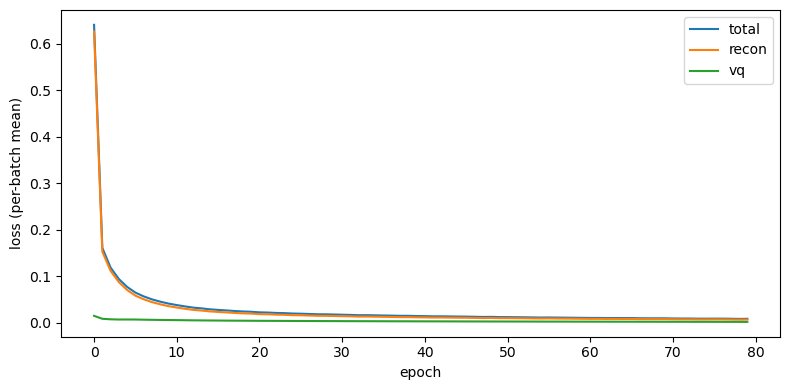

In [9]:
plt.figure(figsize=(8,4))
plt.plot(loss_hist["total"], label="total")
plt.plot(loss_hist["recon"], label="recon")
plt.plot(loss_hist["vq"],    label="vq")
plt.xlabel("epoch"); plt.ylabel("loss (per-batch mean)")
plt.legend(); plt.tight_layout(); plt.show()

## 4) Stage II — Fit Structural Statistics
Estimate unary and pairwise likelihoods on discrete latent maps.

In [ ]:
@torch.no_grad()
def fit_structural_stats(model, loader, device, num_codes, alpha=1.0, use_h=True, use_v=True):
    
    model.eval()
    unary_counts = None
    pair_counts  = torch.zeros(num_codes, num_codes, dtype=torch.float64)
    Hq = Wq = None

    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        _, Z, _ = model.quantize(model.encode(x))
        Z = Z.detach().cpu().long()
        B, H, W = Z.shape

        if unary_counts is None:
            Hq, Wq       = H, W
            unary_counts = torch.zeros(H, W, num_codes, dtype=torch.float64)

        for i in range(H):
            for j in range(W):
                unary_counts[i,j].scatter_add_(0, Z[:,i,j], torch.ones(B, dtype=torch.float64))

        if use_h and W > 1:
            a = Z[:,:,:-1].reshape(-1); b = Z[:,:,1:].reshape(-1)
            pair_counts.index_put_((a,b), torch.ones_like(a, dtype=torch.float64), accumulate=True)
        if use_v and H > 1:
            a = Z[:,:-1,:].reshape(-1); b = Z[:,1:,:].reshape(-1)
            pair_counts.index_put_((a,b), torch.ones_like(a, dtype=torch.float64), accumulate=True)

    unary_prob = (unary_counts+alpha) / (unary_counts.sum(2,keepdim=True) + num_codes*alpha)
    pair_prob  = (pair_counts +alpha) / (pair_counts.sum(1,keepdim=True)  + num_codes*alpha)

    return {
        "unary_counts": unary_counts.float(),
        "unary_prob":   unary_prob.float(),
        "pair_counts":  pair_counts.float(),
        "pair_prob":    pair_prob.float(),
        "meta":   torch.tensor([Hq, Wq, num_codes], dtype=torch.int32),
        "alpha":  torch.tensor([alpha]),
        "use_hv": torch.tensor([1 if use_h else 0, 1 if use_v else 0], dtype=torch.int32),
    }



stats_loader, _, _ = make_loader(CFG["train_dir"], shuffle=False)
print(f"Stats loader: {len(stats_loader)} batches, augment=OFF")

stats = fit_structural_stats(
    model, stats_loader, device,
    num_codes=CFG["num_codes"],
    alpha=CFG["alpha"],
    use_h=CFG["use_h"],
    use_v=CFG["use_v"],
)
torch.save(stats, out_dir/"struct_stats.pt")
print("Stats saved:", out_dir/"struct_stats.pt")
print("unary_prob:", tuple(stats["unary_prob"].shape), "  pair_prob:", tuple(stats["pair_prob"].shape))

# Sanity check
u_sum = stats["unary_prob"].sum(2)
p_sum = stats["pair_prob"].sum(1)
print(f"unary row-sum : min={u_sum.min():.4f} max={u_sum.max():.4f}  (should be ~1.0)")
print(f"pair  row-sum : min={p_sum.min():.4f} max={p_sum.max():.4f}  (should be ~1.0)")

Stats loader: 48 batches, augment=OFF
✅ Stats saved: runs/vqvae_marble/struct_stats.pt
unary_prob: (32, 32, 512)   pair_prob: (512, 512)
unary row-sum : min=1.0000 max=1.0000  (should be ~1.0)
pair  row-sum : min=1.0000 max=1.0000  (should be ~1.0)


## 5) Stage III — Inference
Compute anomaly scores using structural likelihood.

In [ ]:
@torch.no_grad()
def compute_scores_for_batch(Z, unary_prob, pair_prob, lambda1, lambda2,
                              use_h=True, use_v=True, eps=1e-12):
    Zc = Z.detach().cpu().long()
    B, H, W = Zc.shape
    up = unary_prob.cpu(); pp = pair_prob.cpu()

    S_unary = torch.zeros(B, H, W)
    for i in range(H):
        for j in range(W):
            k = Zc[:,i,j]
            S_unary[:,i,j] = -torch.log(up[i,j].gather(0,k).clamp_min(eps))

    S_pair = torch.zeros(B, H, W)
    if use_h and W > 1:
        a = Zc[:,:,:-1]; b = Zc[:,:,1:]
        p = pp[a.reshape(-1), b.reshape(-1)].clamp_min(eps).reshape(B,H,W-1)
        S_pair[:,:,:-1] += -torch.log(p)
    if use_v and H > 1:
        a = Zc[:,:-1,:]; b = Zc[:,1:,:]
        p = pp[a.reshape(-1), b.reshape(-1)].clamp_min(eps).reshape(B,H-1,W)
        S_pair[:,:-1,:] += -torch.log(p)

    return lambda1*S_unary + lambda2*S_pair 


def aggregate_score(S, mode="topk", topk=0.05):
    
    flat = S.view(S.size(0), -1)
    if mode == "max":  return flat.max(1).values
    if mode == "mean": return flat.mean(1)
    if mode == "topk":
        k = max(int(max(min(topk,1),1e-6) * flat.size(1)), 1)
        return torch.topk(flat, k, dim=1).values.mean(1)
    raise ValueError("mode must be max/mean/topk")


@torch.no_grad()
def infer_scores(model, loader, stats):
    model.eval()
    up     = stats["unary_prob"]
    pp     = stats["pair_prob"]
    use_hv = stats.get("use_hv", torch.tensor([1,1], dtype=torch.int32))
    use_h  = bool(use_hv[0].item())
    use_v  = bool(use_hv[1].item())

    results = []
    for bi, (x, y) in enumerate(loader):
        x  = x.to(device, non_blocking=True)
        _, Z, _ = model.quantize(model.encode(x))
        S  = compute_scores_for_batch(Z, up, pp, CFG["lambda1"], CFG["lambda2"], use_h, use_v)
        sc = aggregate_score(S, CFG["aggregate"], CFG["topk"]).cpu()
        for b in range(x.size(0)):
            results.append({
                "index": bi*CFG["batch_size"]+b,
                "label": int(y[b].item()),
                "score": float(sc[b].item()),
            })
    return results


infer_results = infer_scores(model, test_loader, stats)
(out_dir/"infer_scores.json").write_text(json.dumps(infer_results, indent=2), encoding="utf-8")
print(f"Scored {len(infer_results)} test images → {out_dir/'infer_scores.json'}")

✅ Scored 545 test images → runs/vqvae_marble/infer_scores.json


### 5.1 Score Distribution, AUROC, and Top Anomalies
Visualize score separation between normal and defect samples.


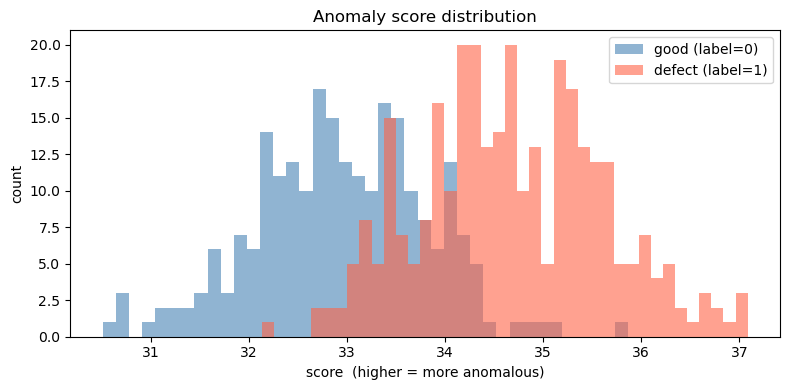

Score stats — min: 30.50  max: 37.09  mean: 33.93  std: 1.25
Good   scores — mean: 32.94  std: 0.88
Defect scores — mean: 34.67  std: 0.94

  AUROC = 0.9138  (91.4%)
  0.5 = random guess  |  1.0 = perfect detection


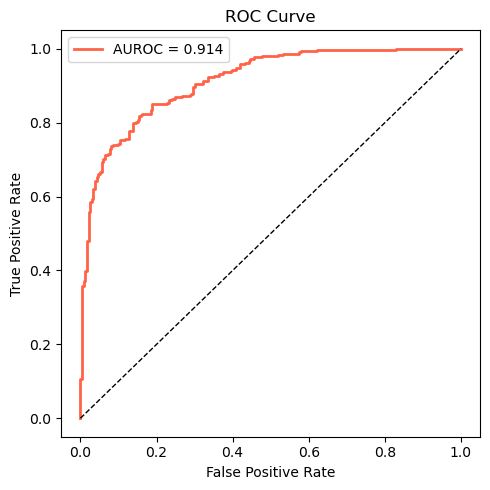


Best threshold (Youden's J): 33.841
  TP=255  FP=36  TN=197  FN=57
  Precision=0.876  Recall=0.817

Top anomaly indices: [143, 191, 29, 287, 39, 244, 81, 74]
Top anomaly scores : [37.09, 37.04, 36.99, 36.9, 36.81, 36.76, 36.64, 36.63]


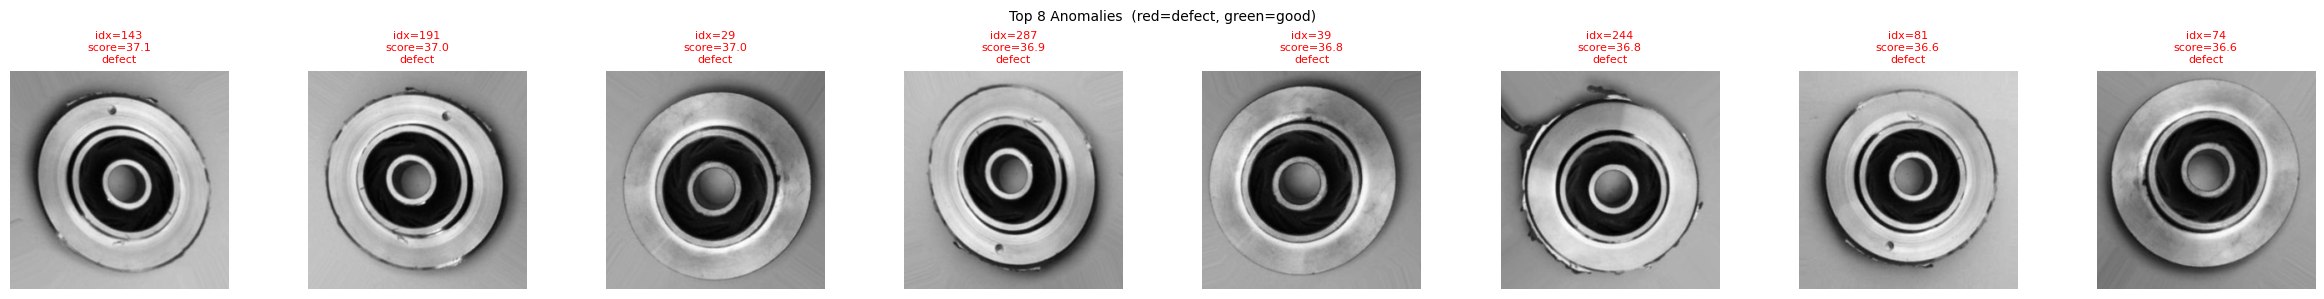

In [ ]:
scores = torch.tensor([r["score"] for r in infer_results])
labels = torch.tensor([r["label"] for r in infer_results])

# ── Score distribution ───────────────────────────────────────────────
plt.figure(figsize=(8,4))
has_defect = (labels == 1).any().item()
if has_defect:
    plt.hist(scores[labels==0].numpy(), bins=40, alpha=0.6, label="good (label=0)",    color="steelblue")
    plt.hist(scores[labels==1].numpy(), bins=40, alpha=0.6, label="defect (label=1)",  color="tomato")
    plt.legend()
else:
    plt.hist(scores.numpy(), bins=50, color="steelblue")
plt.title("Anomaly score distribution")
plt.xlabel("score  (higher = more anomalous)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

print(f"Score stats — min: {scores.min():.2f}  max: {scores.max():.2f}  "
      f"mean: {scores.mean():.2f}  std: {scores.std():.2f}")
if has_defect:
    good_scores   = scores[labels==0]
    defect_scores = scores[labels==1]
    print(f"Good   scores — mean: {good_scores.mean():.2f}  std: {good_scores.std():.2f}")
    print(f"Defect scores — mean: {defect_scores.mean():.2f}  std: {defect_scores.std():.2f}")

# ── AUROC ────────────────────────────────────────────────────────────
if has_defect and SKLEARN_OK:
    auroc = roc_auc_score(labels.numpy(), scores.numpy())
    print(f"\n{'='*40}")
    print(f"  AUROC = {auroc:.4f}  ({auroc*100:.1f}%)")
    print(f"{'='*40}")
    print("  0.5 = random guess  |  1.0 = perfect detection")

    # ROC curve
    fpr, tpr, thresholds = roc_curve(labels.numpy(), scores.numpy())
    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, color="tomato", lw=2, label=f"AUROC = {auroc:.3f}")
    plt.plot([0,1],[0,1], "k--", lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve"); plt.legend(); plt.tight_layout(); plt.show()

    # Best threshold (Youden's J)
    j_scores   = tpr - fpr
    best_idx   = int(np.argmax(j_scores))
    best_thresh = float(thresholds[best_idx])
    pred        = (scores >= best_thresh).long()
    tp = int(((pred==1)&(labels==1)).sum())
    fp = int(((pred==1)&(labels==0)).sum())
    tn = int(((pred==0)&(labels==0)).sum())
    fn = int(((pred==0)&(labels==1)).sum())
    precision = tp/(tp+fp) if (tp+fp)>0 else 0
    recall    = tp/(tp+fn) if (tp+fn)>0 else 0
    print(f"\nBest threshold (Youden's J): {best_thresh:.3f}")
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    print(f"  Precision={precision:.3f}  Recall={recall:.3f}")
elif has_defect and not SKLEARN_OK:
    print("Install scikit-learn to compute AUROC: pip install scikit-learn")
else:
    print("Test set only has good images — add defect/ subfolder to compute AUROC")

# ── Top anomalies ────────────────────────────────────────────────────
print()
N       = 8
top_idx = torch.topk(scores, k=min(N, len(scores))).indices.tolist()
print("Top anomaly indices:", top_idx)
print("Top anomaly scores :", [round(float(scores[i]),2) for i in top_idx])

fig, axes = plt.subplots(1, len(top_idx), figsize=(3*len(top_idx), 3))
if len(top_idx) == 1: axes = [axes]
for ax, i in zip(axes, top_idx):
    img, lab = test_ds[i]
    show = img[0] if img.shape[0]==1 else img.permute(1,2,0)
    color = "red" if lab==1 else "green"
    ax.imshow(show.cpu(), cmap="gray" if img.shape[0]==1 else None)
    ax.set_title(f"idx={i}\nscore={scores[i]:.1f}\n{'defect' if lab==1 else 'good'}", 
                 fontsize=8, color=color)
    ax.axis("off")
plt.suptitle("Top 8 Anomalies  (red=defect, green=good)", fontsize=10)
plt.tight_layout()
plt.show()

## 6) Reconstruction Visualization
Compare original vs reconstructed images.

=== Good images ===
Saved: runs/vqvae_marble/recon_good.png


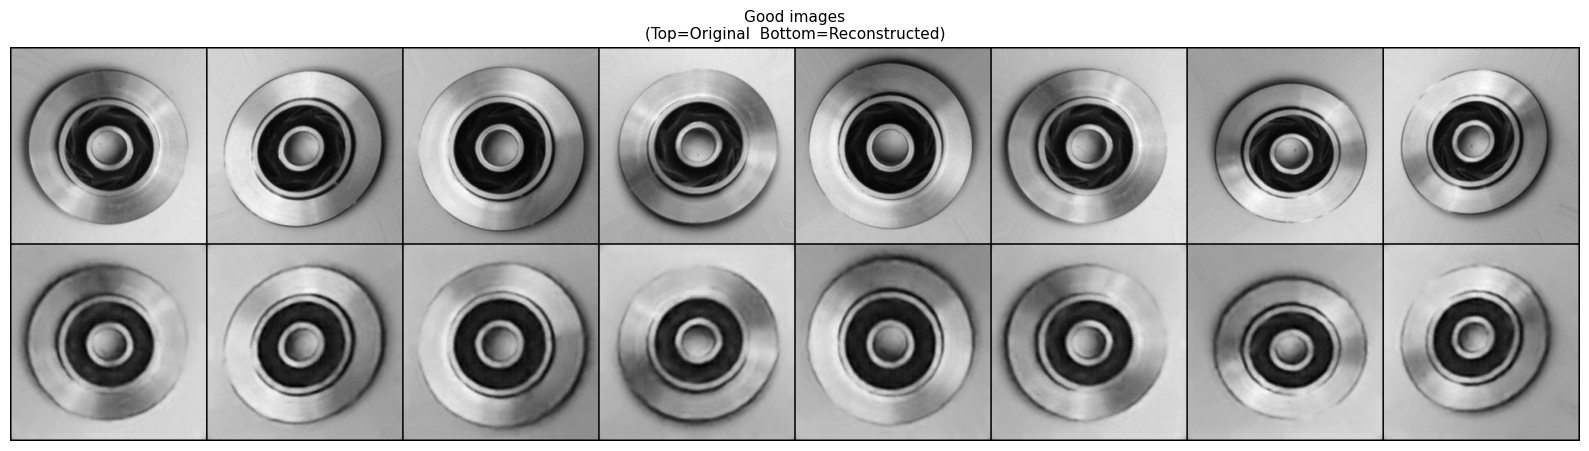


=== Defect images ===
Saved: runs/vqvae_marble/recon_defect.png


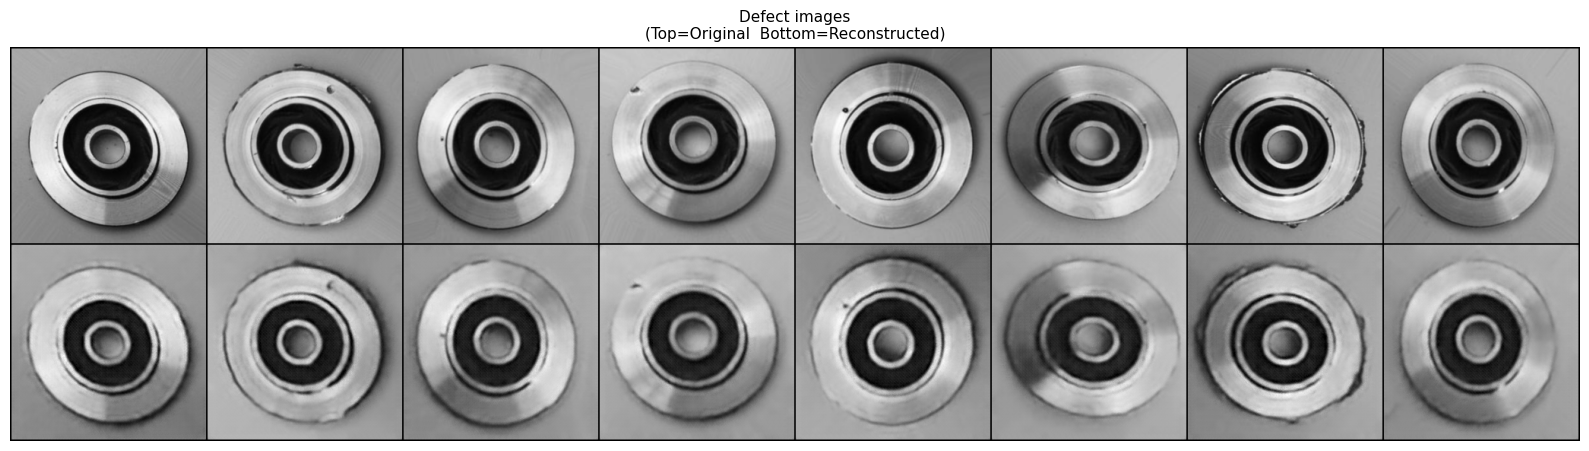

In [ ]:
@torch.no_grad()
def show_reconstructions(model, dataset, device, n=8, title="Reconstruction", save_path=None):

    model.eval()
    indices = torch.randperm(len(dataset))[:n].tolist()

    imgs  = torch.stack([dataset[i][0] for i in indices])  # [n, C, H, W]
    imgs  = imgs.to(device)
    x_hat, _, _ = model(imgs)

    
    if CFG.get("normalize", False):
        imgs  = imgs  * 0.5 + 0.5
        x_hat = x_hat * 0.5 + 0.5

    imgs  = imgs.clamp(0, 1).cpu()
    x_hat = x_hat.clamp(0, 1).cpu()

    
    combined = torch.cat([imgs, x_hat], dim=0)  # [2n, C, H, W]
    grid = make_grid(combined, nrow=n, padding=2)

    plt.figure(figsize=(2*n, 5))
    plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray" if CFG["channels"]==1 else None)
    plt.axis("off")
    plt.title(f"{title}\n(Top=Original  Bottom=Reconstructed)", fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()



print("=== Good images ===")
good_indices = [i for i,(_, lab) in enumerate(test_ds) if lab == 0]
good_subset  = torch.utils.data.Subset(test_ds, good_indices)
show_reconstructions(model, good_subset, device, n=8,
                     title="Good images",
                     save_path=str(out_dir/"recon_good.png"))


print("\n=== Defect images ===")
defect_indices = [i for i,(_, lab) in enumerate(test_ds) if lab == 1]
defect_subset  = torch.utils.data.Subset(test_ds, defect_indices)
show_reconstructions(model, defect_subset, device, n=8,
                     title="Defect images",
                     save_path=str(out_dir/"recon_defect.png"))

## 7) Reconstruction Quality Metrics — MSE / SSIM / PSNR
Quantitative reconstruction metrics for normal vs defect samples.

Computing metrics for good images...
Computing metrics for defect images...

Metric                         Good           Defect
-------------------------------------------------------
N samples                       233              312
MSE (↓)                 0.00142±0.0003      0.00149±0.0004
PSNR dB (↑)               28.57±0.86        28.39±1.06
SSIM (↑)                 0.8669±0.0144       0.8564±0.0133

解讀：
  MSE  Good < Defect → ✅
  PSNR Good > Defect → ✅
  SSIM Good > Defect → ✅


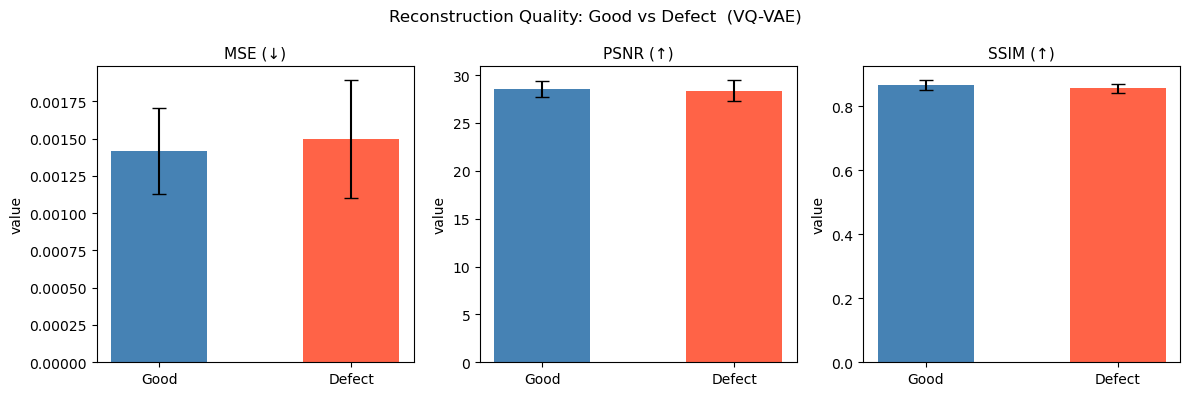

Saved: runs/vqvae_marble/recon_metrics.png
Metrics saved: runs/vqvae_marble/recon_metrics.json


In [ ]:
try:
    from skimage.metrics import structural_similarity as ssim_fn
    SKIMAGE_OK = True
except ImportError:
    print("⚠️  scikit-image not found. Run: pip install scikit-image")
    SKIMAGE_OK = False


@torch.no_grad()
def compute_reconstruction_metrics(model, dataset, device, label_name=""):
    """
    - MSE  : Mean Squared Error
    - PSNR : Peak Signal-to-Noise Ratio
    - SSIM : Structural Similarity Index
    """
    model.eval()
    mse_list  = []
    psnr_list = []
    ssim_list = []

    loader = DataLoader(dataset, batch_size=CFG["batch_size"],
                        shuffle=False, num_workers=CFG["num_workers"])

    for x, _ in loader:
        x     = x.to(device)
        x_hat, _, _ = model(x)

        
        if CFG.get("normalize", False):
            x     = x     * 0.5 + 0.5
            x_hat = x_hat * 0.5 + 0.5
        x     = x.clamp(0, 1).cpu()
        x_hat = x_hat.clamp(0, 1).cpu()

        for i in range(x.size(0)):
            orig = x[i].numpy()      # [C, H, W]
            recon = x_hat[i].numpy()

            # MSE
            mse = float(((orig - recon) ** 2).mean())
            mse_list.append(mse)

            # PSNR（MSE=0 => 100dB）
            psnr = 10 * math.log10(1.0 / mse) if mse > 1e-10 else 100.0
            psnr_list.append(psnr)

            # SSIM
            if SKIMAGE_OK:
                orig_hw  = orig[0]  if orig.shape[0]  == 1 else orig.transpose(1,2,0)
                recon_hw = recon[0] if recon.shape[0] == 1 else recon.transpose(1,2,0)
                s = ssim_fn(orig_hw, recon_hw,
                            data_range=1.0,
                            channel_axis=None if orig.shape[0]==1 else -1)
                ssim_list.append(float(s))

    results = {
        "label":    label_name,
        "n":        len(mse_list),
        "mse_mean": float(np.mean(mse_list)),
        "mse_std":  float(np.std(mse_list)),
        "psnr_mean":float(np.mean(psnr_list)),
        "psnr_std": float(np.std(psnr_list)),
    }
    if SKIMAGE_OK:
        results["ssim_mean"] = float(np.mean(ssim_list))
        results["ssim_std"]  = float(np.std(ssim_list))
    return results


good_indices   = [i for i,(_, lab) in enumerate(test_ds) if lab == 0]
defect_indices = [i for i,(_, lab) in enumerate(test_ds) if lab == 1]

good_subset   = torch.utils.data.Subset(test_ds, good_indices)
defect_subset = torch.utils.data.Subset(test_ds, defect_indices)

print("Computing metrics for good images...")
good_metrics   = compute_reconstruction_metrics(model, good_subset,   device, "good")

print("Computing metrics for defect images...")
defect_metrics = compute_reconstruction_metrics(model, defect_subset, device, "defect")


print()
print("=" * 55)
print(f"{'Metric':<18} {'Good':>16} {'Defect':>16}")
print("-" * 55)
print(f"{'N samples':<18} {good_metrics['n']:>16} {defect_metrics['n']:>16}")
print(f"{'MSE (↓)':<18} {good_metrics['mse_mean']:>12.5f}±{good_metrics['mse_std']:.4f} "
      f"{defect_metrics['mse_mean']:>12.5f}±{defect_metrics['mse_std']:.4f}")
print(f"{'PSNR dB (↑)':<18} {good_metrics['psnr_mean']:>12.2f}±{good_metrics['psnr_std']:.2f} "
      f"{defect_metrics['psnr_mean']:>12.2f}±{defect_metrics['psnr_std']:.2f}")
if SKIMAGE_OK:
    print(f"{'SSIM (↑)':<18} {good_metrics['ssim_mean']:>12.4f}±{good_metrics['ssim_std']:.4f} "
          f"{defect_metrics['ssim_mean']:>12.4f}±{defect_metrics['ssim_std']:.4f}")
print("=" * 55)
print()
print("Interpretation：")
print(f"  MSE  Good < Defect → {'better' if good_metrics['mse_mean'] < defect_metrics['mse_mean'] else 'worse'}")
print(f"  PSNR Good > Defect → {'better' if good_metrics['psnr_mean'] > defect_metrics['psnr_mean'] else 'worse'}")
if SKIMAGE_OK:
    print(f"  SSIM Good > Defect → {'better' if good_metrics['ssim_mean'] > defect_metrics['ssim_mean'] else 'worse'}")

metrics_names = ["MSE (↓)", "PSNR (↑)"]
good_vals     = [good_metrics["mse_mean"],  good_metrics["psnr_mean"]]
defect_vals   = [defect_metrics["mse_mean"], defect_metrics["psnr_mean"]]
good_errs     = [good_metrics["mse_std"],   good_metrics["psnr_std"]]
defect_errs   = [defect_metrics["mse_std"],  defect_metrics["psnr_std"]]

if SKIMAGE_OK:
    metrics_names.append("SSIM (↑)")
    good_vals.append(good_metrics["ssim_mean"])
    defect_vals.append(defect_metrics["ssim_mean"])
    good_errs.append(good_metrics["ssim_std"])
    defect_errs.append(defect_metrics["ssim_std"])

fig, axes = plt.subplots(1, len(metrics_names), figsize=(4*len(metrics_names), 4))
if len(metrics_names) == 1: axes = [axes]
x = np.arange(2)
for ax, name, gv, dv, ge, de in zip(axes, metrics_names, good_vals, defect_vals, good_errs, defect_errs):
    bars = ax.bar(["Good", "Defect"], [gv, dv], yerr=[ge, de],
                  color=["steelblue","tomato"], capsize=5, width=0.5)
    ax.set_title(name, fontsize=11)
    ax.set_ylabel("value")
plt.suptitle("Reconstruction Quality: Good vs Defect  (VQ-VAE)", fontsize=12)
plt.tight_layout()
plt.savefig(str(out_dir/"recon_metrics.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_dir/"recon_metrics.png")


comparison = {"model": "VQ-VAE", "good": good_metrics, "defect": defect_metrics,
              "auroc": float(auroc) if 'auroc' in dir() else None}
(out_dir/"recon_metrics.json").write_text(json.dumps(comparison, indent=2), encoding="utf-8")
print("Metrics saved:", out_dir/"recon_metrics.json")